You measure the position of a star $N$ times with the *same* telescope i.e. errors are homoscedastic. Let's say the underlying process is Gaussian, the true position is $\mu = 1$ (in suitable units), and the erorrs are $\sigma=0.2$

### Part 1

- Generate fake measurements. Treat each of these observations as an estimate of the true distribution. So we'll center a Gaussian (with the known $\sigma$) at each point. This is the probability of each data point, $p(x_i|\mu,\sigma)$.
- Plot each of the individual likelihoods separately.  Also plot their product (i.e. the likelihood of the dataset $\{x_i\}$). Make sure the x grid has enough points.
- Just read off the maximum likelihood solution (e.g. using `np.argsort`) 
- Compare it with the MLE estimator derived above


In [60]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

In [61]:
sigma = 0.2
N = 50
x = norm(1,sigma).rvs(N)


In [62]:
M = 1000
prod = np.ones(M)
x_grid = np.linspace(0,2,M)
for i,loc in enumerate(x_grid):
    g = norm(loc, sigma)
    gauss = g.pdf(x)
    prod[i] = np.prod(gauss) # computing the product of the likelihood of each x point being drawn from the gaussian centered at loc
                            # the likelihood of x coincides with the gaussian pdf computed in x

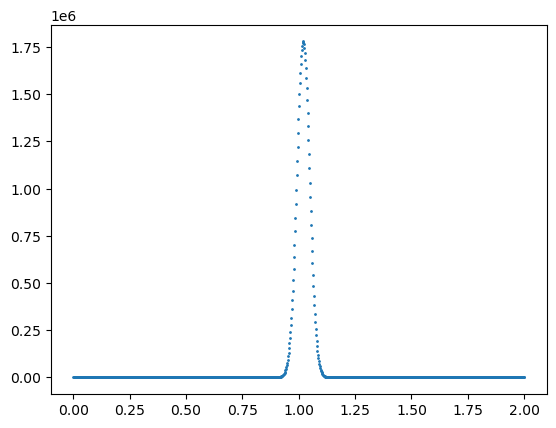

In [63]:
plt.scatter(x_grid, prod, s = 1.)

In [64]:
print('Maximum of the likelihood in x =', x_grid[np.argmax(prod)])
print('Mean of the sample:', np.mean(x))

Maximum of the likelihood in x = 1.019019019019019
Mean of the sample: 1.0195030734552262



### Part 2

Check the Fisher matrix error estimate makes sense
- do a rough $2^\mathrm{nd}$ order differentation of our log-likelihood function with `np.diff`, 
- divide through by our $\Delta \theta^2$ to get the correct normalization, 
- multiply by $-1$, 
- then take the square root.
- Compare with the Fisher matrix error derived above
- Plot a Gaussian at the measured $\mu$ with this error as the scale to see if it matches the numerical likelihood distribution. (The normalization won't be captured, you can rescale it as you like to check it agrees) 


In [65]:
log_like = np.log(prod) # diff has steps of width 1 so I need to correct
fish_err = (np.diff(log_like, 2)/((x_grid[1]-x_grid[0])**2))
fish_err = 1/np.sqrt(-fish_err)[np.argmax(prod)]

In [66]:
print('Fisher estimate of the error of the mean:',fish_err)
print('Error of the mean:' , sigma/np.sqrt(N))

Fisher estimate of the error of the mean: 0.028284271247462724
Error of the mean: 0.0282842712474619


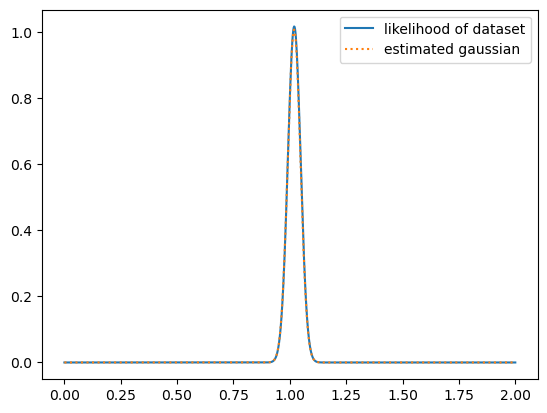

In [76]:
gaussian = norm(x_grid[np.argmax(prod)],fish_err)
plt.plot(x_grid, prod/(1e6*1.75), label = 'likelihood of dataset')
plt.plot(x_grid, gaussian.pdf(x_grid)/14, label = 'estimated gaussian', ls = ':')
plt.legend()


### Part 3

Let's make our model more realistic. Our $N$ measurements were taken in different nights, where the sky behaved differently (i.e. errors are heteoscedastic). Let's assume that each measurment has a $\sigma_i$ that is normally distributed with mean $0.2$ and standard deviation $0.05$

- Generalize your code from above to this case

In [111]:
N = 100
x = norm(1,0.2).rvs(N)

In [112]:
M = 1000
prod_mu = np.ones(M)
x_grid = np.linspace(0,2,M)
sigma = norm(0.2,0.05).rvs(M)
for i,(loc, s) in enumerate(zip(x_grid, sigma)):
    g = norm(loc, s)
    gauss_mu = g.pdf(x)
    prod_mu[i] = np.prod(gauss_mu)

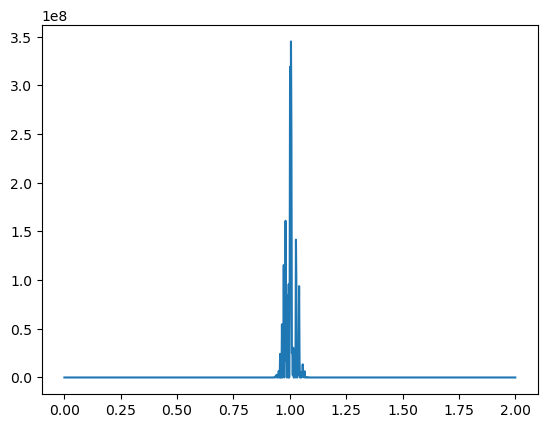

In [113]:
plt.plot(x_grid, prod_mu)

In [114]:
print('Maximum of the likelihood in mu =', x_grid[np.argmax(prod_mu)])
print('Mean of the sample:', np.mean(x))

Maximum of the likelihood in mu = 1.005005005005005
Mean of the sample: 1.0058370967144956


In [101]:
# MLE per sigma

N = 50
M = 1000
x = norm(1,0.2).rvs(M)

prod = np.ones([N,N])
x_grid = np.linspace(0,2,N)
sigma_grid = np.linspace(0.05, 0.35, N)

for i,loc in enumerate(x_grid):
    for j,s in enumerate(sigma_grid):
        g = norm(loc, s)
        gauss = g.pdf(x)
        #plt.scatter(x, gauss)
        prod[i][j] = np.prod(gauss) # computing the product of the likelihood of each x point being drawn from the gaussian centered at loc
                                # the likelihood of x coincides with the gaussian pdf computed in x


In [ ]:
np.floor(np.argmax(prod)%N)

np.int64(25)

In [ ]:
print('Maximum of the likelihood for mu:', x_grid[np.argmax(prod)%N])
print('Maximum of the likelihood for sigma:', sigma_grid[int(np.floor(np.argmax(prod)/N))])
print('Mean of the sample:', np.mean(x))

Maximum of the likelihood for mu: 1.0204081632653061
Maximum of the likelihood for sigma: 0.19693877551020406
Mean of the sample: 0.9915417654733827
